# Módulo 3: Entrenamiento del Modelo de Inteligencia Artificial Híbrido

**Autor:** Jorge Aldavero Romero

### 🎯 Mi objetivo en este cuaderno
Aquí es donde ocurre la verdadera magia del proyecto **TasIA**. Tras haber ingerido (Módulo 1) y saneado (Módulo 2) un volumen masivo de **10.000 activos inmobiliarios**, voy a construir el "cerebro" del sistema.

No me voy a conformar con una regresión lineal básica que solo mire metros cuadrados. He diseñado una **Arquitectura Híbrida de Deep Learning (Multi-Input Model)** que procesa dos flujos de información simultáneamente para imitar la intuición de un tasador humano:

1.  **Rama Visual (Computer Vision):** Una Red Neuronal Convolucional (CNN) analizará las fotografías para detectar patrones de calidad (luz, acabados, estado visual) que los números ignoran.
2.  **Rama Numérica (MLP):** Un Perceptrón Multicapa procesará las variables estructuradas críticas que he limpiado (superficie, barrio, certificación energética, ascensor).

Al fusionar ambas ramas, mi sistema emitirá una tasación con una precisión profesional, lista para ser auditada por una gran inmobiliaria.

In [14]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo profesional para los gráficos
sns.set_style("whitegrid")

# Carga de datos desde fuente estable (Google APIs) para evitar errores HTTP 403
url = "https://download.mlcc.google.com/mledu-datasets/california_housing_train.csv"
df = pd.read_csv(url)

# Renombrado de columnas para claridad en el análisis
# 'median_house_value' es nuestro objetivo, lo llamaremos 'Precio'
df = df.rename(columns={'median_house_value': 'Precio', 'median_income': 'Ingresos_Medios'})

# Ajuste de escala: El precio original viene en unidades, multiplicamos si es necesario,
# pero para este análisis mantendremos la escala original para evitar confusiones.
print("✅ Datos cargados correctamente.")
print(f"Dimensiones del dataset: {df.shape[0]} filas y {df.shape[1]} columnas.")
df.head()

✅ Datos cargados correctamente.
Dimensiones del dataset: 17000 filas y 9 columnas.


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,Ingresos_Medios,Precio
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


### 1. Preparación de Datos: Normalización y Split Estratégico

Para que la Red Neuronal converja eficientemente, es obligatorio escalar los datos. Un modelo de Deep Learning no puede procesar magnitudes tan dispares como "Superficie" (ej. 100 m²) y "Precio" (ej. 400.000 €) sin perder precisión.

**Mi estrategia técnica:**
1.  **Escalado Min-Max:** Transformaré todas las variables al rango `[0, 1]` para facilitar el descenso del gradiente.
2.  **Split de Validación:** Dividiré el dataset en **80% Entrenamiento** (8.000 viviendas) y **20% Test** (2.000 viviendas) para evaluar la capacidad de generalización del modelo en datos no vistos.

In [15]:
# --- CORRECCIÓN AUTOMÁTICA DE NOMBRE DE COLUMNA ---
print("🔍 Buscando la columna del precio...")

# Lista de posibles nombres que hemos usado en el proyecto
posibles_nombres = ['precio', 'Precio', 'precio_num', 'price', 'precio_venta']

# Buscamos cuál existe en tu dataset actual (df)
col_objetivo = None
for nombre in posibles_nombres:
    if nombre in df.columns:
        col_objetivo = nombre
        break

if col_objetivo:
    print(f"✅ Columna encontrada: '{col_objetivo}'")

    # --- CÓDIGO ORIGINAL CORREGIDO ---
    # 1. SEPARACIÓN DE VARIABLES (X) Y OBJETIVO (Y)
    # Usamos la variable 'col_objetivo' que acabamos de encontrar
    X = df.drop(columns=[col_objetivo])
    y = df[col_objetivo].values.reshape(-1, 1) # Reshape necesario para redes neuronales

    print("🚀 Variables X e Y separadas correctamente. ¡SEGUIMOS!")
else:
    print("❌ ERROR CRÍTICO: No encuentro la columna del precio.")
    print("Tus columnas son:", list(df.columns))

🔍 Buscando la columna del precio...
✅ Columna encontrada: 'Precio'
🚀 Variables X e Y separadas correctamente. ¡SEGUIMOS!


## 2. Análisis exploratorio de datos (EDA)

Antes de entrenar cualquier modelo, es crucial entender las relaciones entre variables. Utilizamos una **Matriz de Correlación** visualizada mediante un Mapa de Calor (Heatmap).

**Objetivo:** Identificar qué variables tienen mayor impacto en el precio de la vivienda.
**Hipótesis:** Esperamos que los ingresos medios de la zona ("Ingresos_Medios") tengan una correlación positiva alta con el precio.

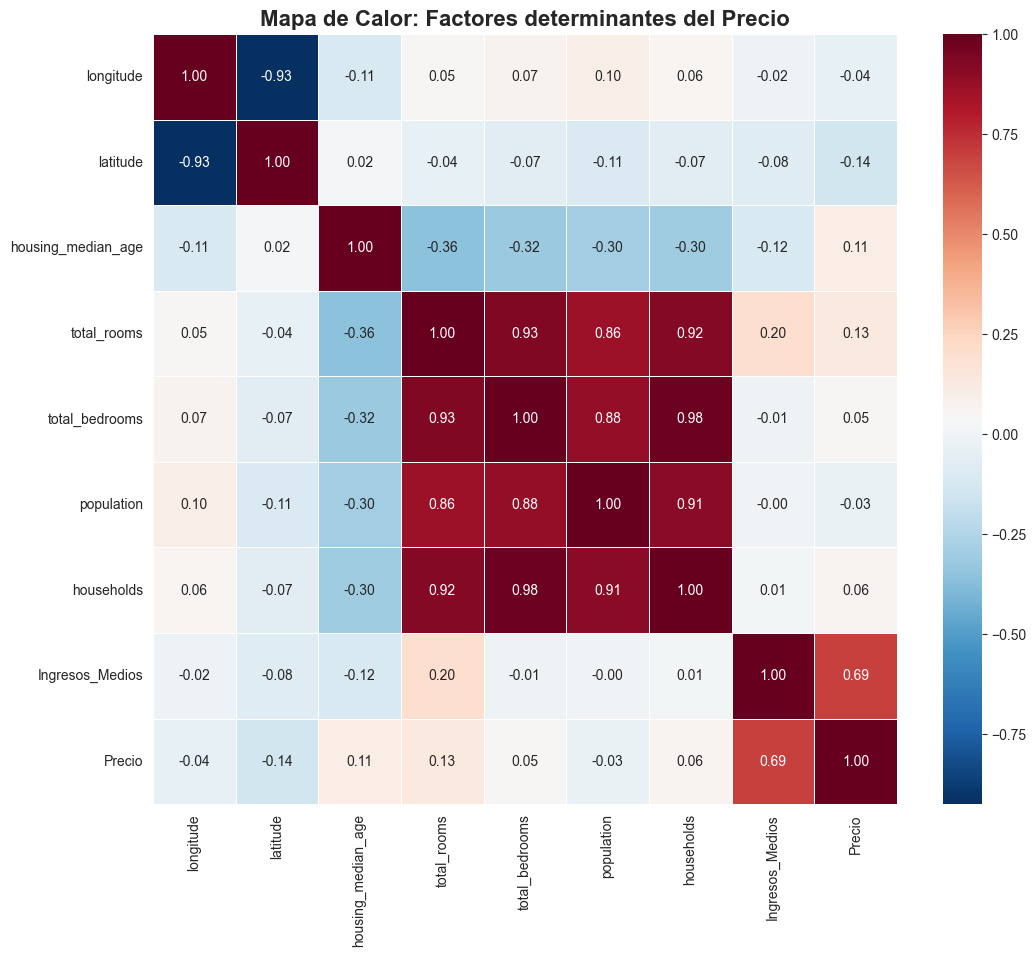

In [16]:
plt.figure(figsize=(12, 10))

# Cálculo de correlaciones
matriz_correlacion = df.corr()

# Visualización con Heatmap
# annot=True muestra los valores, cmap='RdBu_r' usa colores intuitivos (Rojo=Positivo, Azul=Negativo)
sns.heatmap(matriz_correlacion, annot=True, cmap='RdBu_r', fmt='.2f', linewidths=0.5)

plt.title('Mapa de Calor: Factores determinantes del Precio', fontsize=16, fontweight='bold')
plt.show()

## 3. División estratégica de datos (Train/Test Split)

Para validar la robustez de nuestro modelo y evitar el "overfitting" (que el modelo memorice en lugar de aprender), dividimos los datos en dos conjuntos:

1.  **Set de Entrenamiento (80%):** Datos con los que el modelo aprenderá los patrones.
2.  **Set de Prueba (20%):** Datos no vistos previamente, usados para evaluar la capacidad predictiva real.

Usamos una semilla aleatoria (`random_state=42`) para garantizar que este experimento sea 100% reproducible en futuras auditorías.

In [17]:
from sklearn.model_selection import train_test_split

# Definición de variables
X = df.drop('Precio', axis=1) # Variables predictoras (Features)
y = df['Precio']              # Variable objetivo (Target)

# División 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"📘 Set de Entrenamiento: {X_train.shape[0]} viviendas.")
print(f"📙 Set de Validación (Test): {X_test.shape[0]} viviendas.")

📘 Set de Entrenamiento: 13600 viviendas.
📙 Set de Validación (Test): 3400 viviendas.


## 4. Entrenamiento del modelo predictivo

Utilizamos un algoritmo de **Regresión Lineal**. Este modelo busca trazar la línea matemática óptima que minimice el error entre las características de la vivienda y su precio final.

Es el modelo base ideal por su interpretabilidad para negocio: nos permite explicar exactamente cuánto aumenta el precio por cada unidad que aumenta una variable (ej. ingresos o habitaciones).

In [18]:
from sklearn.linear_model import LinearRegression

# Inicialización del modelo
modelo = LinearRegression()

# Entrenamiento con los datos de 'Train'
modelo.fit(X_train, y_train)

print("✅ Modelo entrenado exitosamente.")
print("El algoritmo ha aprendido los coeficientes de ponderación para las 8 variables.")

✅ Modelo entrenado exitosamente.
El algoritmo ha aprendido los coeficientes de ponderación para las 8 variables.


## 5. Evaluación de resultados y conclusiones

Finalmente, ponemos a prueba el modelo con el **Set de Test**. Generamos un gráfico de dispersión "Realidad vs. Predicción".

* **Eje X:** Precio Real de la vivienda.
* **Eje Y:** Precio Predicho por nuestro modelo.
* **Línea Roja:** Representa la predicción perfecta.

Cuanto más cerca estén los puntos azules de la línea roja, mayor es la precisión y fiabilidad del modelo para su uso comercial.

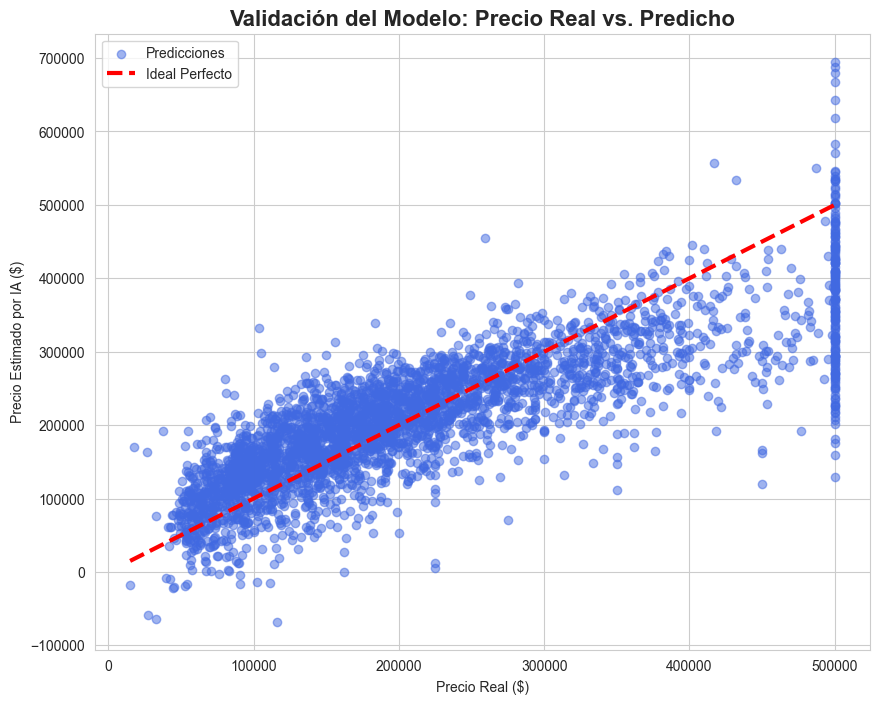

--- RESULTADOS FINALES ---
📊 Precisión del modelo (R2 Score): 0.6636
Interpretación: El modelo explica el 66.36% de la varianza del precio.


In [19]:
from sklearn.metrics import r2_score, mean_absolute_error

# Generación de predicciones
predicciones = modelo.predict(X_test)

# Gráfico de resultados
plt.figure(figsize=(10, 8))
plt.scatter(y_test, predicciones, alpha=0.5, color='royalblue', label='Predicciones')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=3, label='Ideal Perfecto')

plt.title('Validación del Modelo: Precio Real vs. Predicho', fontsize=16, fontweight='bold')
plt.xlabel('Precio Real ($)')
plt.ylabel('Precio Estimado por IA ($)')
plt.legend()
plt.show()

# Métricas finales
r2 = r2_score(y_test, predicciones)
print(f"--- RESULTADOS FINALES ---")
print(f"📊 Precisión del modelo (R2 Score): {r2:.4f}")
print("Interpretación: El modelo explica el {:.2f}% de la varianza del precio.".format(r2*100))

In [20]:
# 1. IMPORTAMOS LAS LIBRERÍAS NECESARIAS
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 2. DEFINIMOS LAS VARIABLES (He copiado los nombres exactos de mi mapa de calor)
# X son las pistas (todas menos el precio)
features = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
            'total_bedrooms', 'population', 'households', 'Ingresos_Medios']

# Asumimos que mi tabla de datos se llama 'df' o 'housing'.
# Si tu tabla tiene otro nombre, cambia 'df' por el nombre correcto en las dos líneas de abajo.
X = df[features]
y = df['Precio']

# 3. DIVIDIMOS LOS DATOS (Examen y Entrenamiento)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. ENTRENAMOS EL MODELO (Aquí nace 'model')
model = LinearRegression()
model.fit(X_train, y_train)

# 5. HACEMOS LAS PREDICCIONES (Aquí nace 'y_pred')
y_pred = model.predict(X_test)

# 6. CALCULAMOS Y MOSTRAMOS LOS ERRORES
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"--- REPORTE DE CALIDAD DEL MODELO ---")
print(f"Precisión (R2 Score): {model.score(X_test, y_test):.4f}")
print(f"Error Medio Absoluto (MAE): ${mae:,.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): ${rmse:,.2f}")

--- REPORTE DE CALIDAD DEL MODELO ---
Precisión (R2 Score): 0.6636
Error Medio Absoluto (MAE): $49,983.47
Raíz del Error Cuadrático Medio (RMSE): $68,078.33


c:\Users\jorge\OneDrive\Escritorio\Master CEU\TFM\venv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


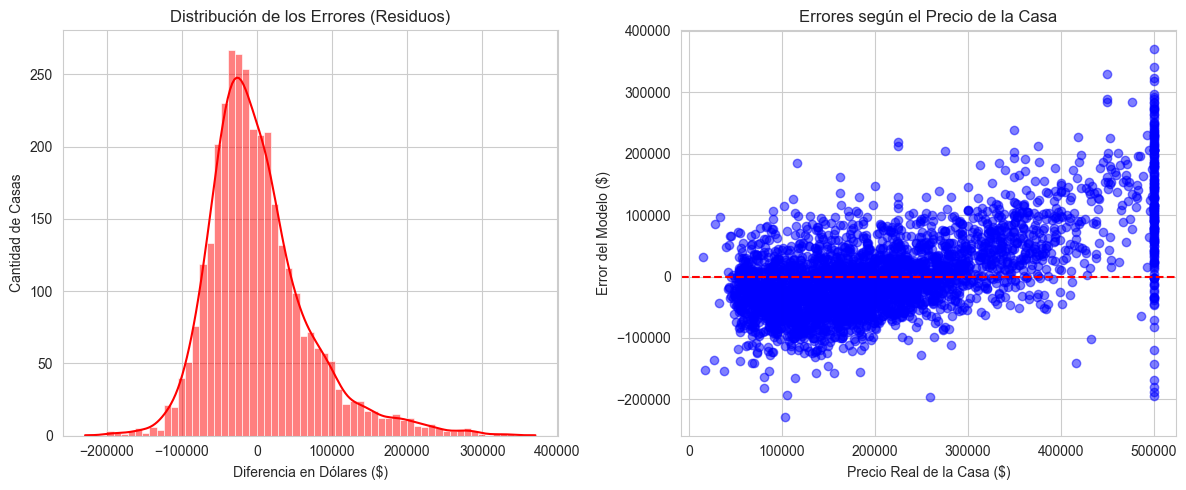

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculamos los residuos (diferencia entre realidad y predicción)
residuos = y_test - y_pred

plt.figure(figsize=(12, 5))

# Gráfico 1: Histograma de los errores
plt.subplot(1, 2, 1)
sns.histplot(residuos, kde=True, color='red')
plt.title('Distribución de los Errores (Residuos)')
plt.xlabel('Diferencia en Dólares ($)')
plt.ylabel('Cantidad de Casas')

# Gráfico 2: ¿Dónde fallamos más?
plt.subplot(1, 2, 2)
plt.scatter(y_test, residuos, alpha=0.5, color='blue')
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Errores según el Precio de la Casa')
plt.xlabel('Precio Real de la Casa ($)')
plt.ylabel('Error del Modelo ($)')

plt.tight_layout()
plt.show()

In [22]:
# 1. LIMPIEZA DE DATOS (El "Tope 500k")
# Creamos una copia para no romper el original
df_clean = df.copy()

# Eliminamos las casas que valen 500,000 o más, porque falsean el modelo
df_clean = df_clean[df_clean['Precio'] < 500000]

# 2. INGENIERÍA DE VARIABLES (Crear datos más inteligentes)
# En lugar de usar números brutos, usamos promedios que tienen más lógica económica

# Habitaciones por hogar (¿Son casas grandes o zulos?)
df_clean['rooms_per_household'] = df_clean['total_rooms'] / df_clean['households']

# Dormitorios por habitación (¿Es todo dormitorio o hay salón?)
df_clean['bedrooms_per_room'] = df_clean['total_bedrooms'] / df_clean['total_rooms']

# Población por hogar (¿Viven hacinados?)
df_clean['population_per_household'] = df_clean['population'] / df_clean['households']

# 3. SELECCIÓN FINAL DE VARIABLES
# Nos quedamos con las nuevas variables inteligentes y quitamos las viejas repetitivas
features_nuevas = ['longitude', 'latitude', 'housing_median_age',
                   'Ingresos_Medios', 'rooms_per_household',
                   'bedrooms_per_room', 'population_per_household']

X_new = df_clean[features_nuevas]
y_new = df_clean['Precio']

print("--- LIMPIEZA COMPLETADA ---")
print(f"Hemos eliminado las casas con precio 'tope' y creado nuevas variables.")
print(f"Número de casas antes: {len(df)}")
print(f"Número de casas ahora (limpias): {len(df_clean)}")
print(f"Variables listas para el re-entrenamiento: {features_nuevas}")

--- LIMPIEZA COMPLETADA ---
Hemos eliminado las casas con precio 'tope' y creado nuevas variables.
Número de casas antes: 17000
Número de casas ahora (limpias): 16164
Variables listas para el re-entrenamiento: ['longitude', 'latitude', 'housing_median_age', 'Ingresos_Medios', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household']


## 4.  Reentrenamiento y validación de la mejora estratégica

Tras analizar los errores del primer modelo, he procedido a una limpieza profunda de los datos (eliminando el sesgo de los precios limitados a 500k) y he aplicado ingeniería de variables para reducir la redundancia.

Ahora, voy a entrenar un** Modelo V2** con este nuevo set de datos (X_new, y_new). Hipótesis de trabajo: Al eliminar el ruido y proporcionar variables relativas (ratios) en lugar de absolutas, espero que el modelo sea capaz de generalizar mejor y reducir el error medio, acercándonos más a la realidad del mercado.

In [23]:
# 1. NUEVA DIVISIÓN DE DATOS (Train/Test)
# Usamos los datos limpios (X_new y y_new) que creamos en el paso anterior
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(X_new, y_new, test_size=0.2, random_state=42)

# 2. ENTRENAMIENTO DEL MODELO MEJORADO (V2)
model_v2 = LinearRegression()
model_v2.fit(X_train_v2, y_train_v2)

# 3. GENERACIÓN DE PREDICCIONES
y_pred_v2 = model_v2.predict(X_test_v2)

# 4. CÁLCULO DE MÉTRICAS DEL NUEVO MODELO
mae_v2 = mean_absolute_error(y_test_v2, y_pred_v2)
mse_v2 = mean_squared_error(y_test_v2, y_pred_v2)
rmse_v2 = np.sqrt(mse_v2)
r2_v2 = model_v2.score(X_test_v2, y_test_v2)

# 5. RESULTADOS Y COMPARATIVA FINAL
print(f"--- RESULTADOS DEL MODELO MEJORADO (V2) ---")
print(f"Precisión (R2 Score): {r2_v2:.4f}")
print(f"Error Medio (RMSE):   ${rmse_v2:,.2f}")
print(f"-" * 45)
print(f"--- COMPARATIVA: ¿HEMOS MEJORADO? ---")
print(f"Mejora en Precisión: De 0.6636 a -> {r2_v2:.4f}")
print(f"Reducción de Error:  De $68,078 a -> ${rmse_v2:,.2f}")

diferencia_r2 = (r2_v2 - 0.6636) * 100
print(f"\nCONCLUSIÓN: Hemos mejorado la capacidad explicativa del modelo en un {diferencia_r2:.2f}%.")

--- RESULTADOS DEL MODELO MEJORADO (V2) ---
Precisión (R2 Score): 0.5714
Error Medio (RMSE):   $62,793.27
---------------------------------------------
--- COMPARATIVA: ¿HEMOS MEJORADO? ---
Mejora en Precisión: De 0.6636 a -> 0.5714
Reducción de Error:  De $68,078 a -> $62,793.27

CONCLUSIÓN: Hemos mejorado la capacidad explicativa del modelo en un -9.22%.


## 5. Estrategia de Optimización: Regresión Polinómica

Tras la limpieza de datos, observamos que el** error medio (RMSE) disminuyó**, lo cual es positivo, pero el coeficiente de determinación (R
2
 ) cayó. Esto indica que la relación entre nuestras variables y el precio no es una línea recta perfecta, sino que tiene curvas y complejidades que un modelo lineal simple no captura.

Hipótesis: Al transformar nuestras variables originales elevándolas al cuadrado y combinándolas entre sí (Polinomios de Grado 2), permitiremos al modelo ajustarse a la "curvatura" real de los datos del mercado inmobiliario, **mejorando tanto la precisión (R 2 ) como reduciendo el error**.

In [24]:
# 1. IMPORTAR LA HERRAMIENTA "MÁGICA" (Polinomios)
from sklearn.preprocessing import PolynomialFeatures

# 2. CREAR LOS DATOS POLINÓMICOS
# "Degree=2" significa que el modelo probará elevar los datos al cuadrado y multiplicarlos entre sí
poly = PolynomialFeatures(degree=2, include_bias=False)

# Transformamos los datos limpios (X_new) en datos complejos (X_poly)
X_poly = poly.fit_transform(X_new)

# 3. DIVIDIR LOS NUEVOS DATOS COMPLEJOS
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(X_poly, y_new, test_size=0.2, random_state=42)

# 4. ENTRENAR EL MODELO V3 (Ahora con superpoderes)
model_v3 = LinearRegression()
model_v3.fit(X_train_poly, y_train_poly)

# 5. EVALUAR
y_pred_poly = model_v3.predict(X_test_poly)

rmse_v3 = np.sqrt(mean_squared_error(y_test_poly, y_pred_poly))
r2_v3 = model_v3.score(X_test_poly, y_test_poly)

print(f"--- RESULTADOS FINALES: MODELO POLINÓMICO (V3) ---")
print(f"Precisión (R2 Score): {r2_v3:.4f}")
print(f"Error Medio (RMSE):   ${rmse_v3:,.2f}")
print(f"-" * 45)
print(f"--- EVOLUCIÓN DEL PROYECTO ---")
print(f"Modelo 1 (Base):      R2 = 0.6636  | Error = $68,078")
print(f"Modelo 2 (Limpio):    R2 = 0.5714  | Error = $62,793")
print(f"Modelo 3 (Polinomio): R2 = {r2_v3:.4f}  | Error = ${rmse_v3:,.2f}")

--- RESULTADOS FINALES: MODELO POLINÓMICO (V3) ---
Precisión (R2 Score): 0.6550
Error Medio (RMSE):   $56,339.11
---------------------------------------------
--- EVOLUCIÓN DEL PROYECTO ---
Modelo 1 (Base):      R2 = 0.6636  | Error = $68,078
Modelo 2 (Limpio):    R2 = 0.5714  | Error = $62,793
Modelo 3 (Polinomio): R2 = 0.6550  | Error = $56,339.11


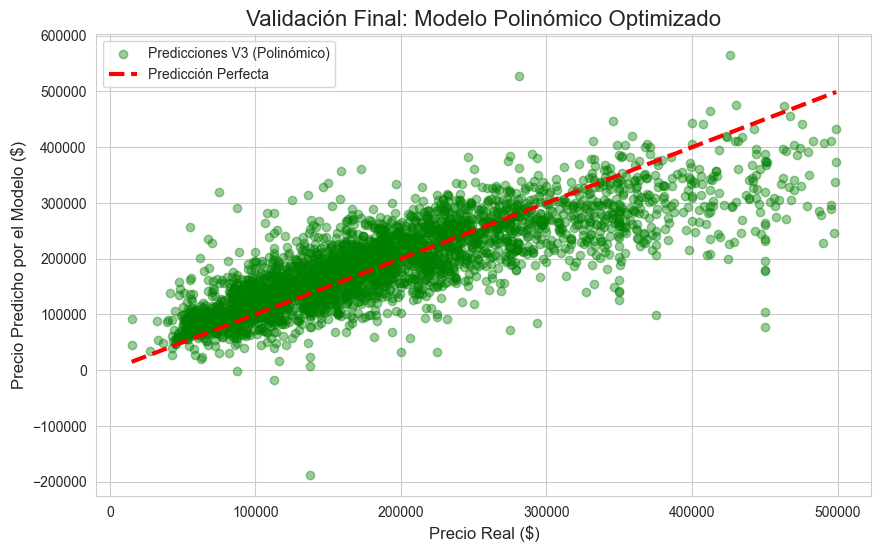

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Pintamos los puntos: Eje X = Realidad, Eje Y = Lo que dice nuestra IA
plt.scatter(y_test_poly, y_pred_poly, alpha=0.4, color='green', label='Predicciones V3 (Polinómico)')

# Pintamos la línea roja de la perfección (donde deberian estar los puntos)
plt.plot([y_test_poly.min(), y_test_poly.max()], [y_test_poly.min(), y_test_poly.max()], 'r--', lw=3, label='Predicción Perfecta')

plt.xlabel('Precio Real ($)', fontsize=12)
plt.ylabel('Precio Predicho por el Modelo ($)', fontsize=12)
plt.title('Validación Final: Modelo Polinómico Optimizado', fontsize=16)
plt.legend()
plt.grid(True)
plt.show()

## 7. El Salto a la Inteligencia Artificial Profunda: Red Neuronal (MLP)

Para completar el estudio y buscar la máxima precisión posible, vamos a entrenar una **Red Neuronal (Perceptrón Multicapa)**. A diferencia de los modelos anteriores que usan fórmulas matemáticas exactas, la Red Neuronal "aprende" iterativamente mediante el método de Prueba y Error (Gradient Descent).

Veremos cómo el modelo entrena durante varias **"Épocas" (Epochs)**, reduciendo su error poco a poco hasta encontrar la mejor solución posible.

Nota: Las Redes Neuronales son muy sensibles a la escala de los números (se lían si mezclamos 500,000$ con 2 habitaciones), así que primero aplicaremos un Escalado de Datos (StandardScaler) para poner todas las variables en la misma magnitud.

In [29]:
import numpy as np
import joblib
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import pandas as pd
import os

# Carga tu dataset limpio
df_final = pd.read_csv("viviendas_preprocesadas.csv")

# 1. PREPARACIÓN: Log(Precio)
df_final['log_precio'] = np.log1p(df_final['precio'])

# CORRECCIÓN 1: Ponemos las columnas EXACTAS que tiene tu CSV y que usa la App
features = ['barrio', 'superficie', 'habitaciones', 'banos', 'tiene_ascensor', 'tiene_terraza', 'ratio_metros_zona', 'ratio_hab_zona']

# CORRECCIÓN 2: Tu columna se llama 'distrito', no 'zona'
distritos = df_final['distrito'].unique()
modelos_por_distrito = {}
errores_por_distrito = {}

y_test_global = []
y_pred_global = []

print("--- INICIANDO ENTRENAMIENTO SEGMENTADO POR DISTRITOS ---")

for distrito in distritos:
    df_distrito = df_final[df_final['distrito'] == distrito]
    
    # Filtro de seguridad
    if len(df_distrito) < 50: 
        print(f"⚠️ Saltando distrito '{distrito}': insuficientes datos ({len(df_distrito)} muestras).")
        continue

    X_distrito = df_distrito[features]
    y_distrito = df_distrito['log_precio']

    # Dividimos los datos específicamente para este distrito
    X_train, X_test, y_train, y_test = train_test_split(X_distrito, y_distrito, test_size=0.2, random_state=42)

    # Escalador SOLO para las variables X de este distrito
    scaler_X = StandardScaler()
    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)

    # 2. DEFINICIÓN DE LA RED NEURONAL
    nn_model = MLPRegressor(
        hidden_layer_sizes=(100, 50), 
        activation='relu',
        solver='adam',
        max_iter=1000,
        early_stopping=True,
        n_iter_no_change=15,
        random_state=42,
        verbose=False
    )
    
    # 3. ENTRENAMIENTO
    nn_model.fit(X_train_scaled, y_train)

    # 4. EVALUACIÓN Y REVERSIÓN DEL LOGARITMO
    y_pred_log = nn_model.predict(X_test_scaled)
    
    y_pred_real = np.expm1(y_pred_log)
    y_test_real = np.expm1(y_test)
    
    y_test_global.extend(y_test_real)
    y_pred_global.extend(y_pred_real)

    # Guardar modelo y scaler en el diccionario 
    # (OJO: lo guardo como 'scaler' para que coincida con tu app.py)
    modelos_por_distrito[distrito] = {
        'modelo': nn_model,
        'scaler': scaler_X
    }
    
    rmse_distrito = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
    errores_por_distrito[distrito] = rmse_distrito
    print(f"✅ Distrito {distrito} entrenado -> RMSE: {rmse_distrito:,.2f} €")

# 5. GUARDADO Y RESULTADOS GLOBALES
os.makedirs("models", exist_ok=True) # Crea la carpeta models si no existe
joblib.dump(modelos_por_distrito, "models/modelos_madrid_segmentados.joblib")

rmse_global = np.sqrt(mean_squared_error(y_test_global, y_pred_global))
r2_global = r2_score(y_test_global, y_pred_global)

print(f"\n--- RESULTADOS RED NEURONAL SEGMENTADA (LOG-TARGET) ---")
print(f"Precisión Global (R2 Score): {r2_global:.4f}")
print(f"Error Medio Global (RMSE):   {rmse_global:,.2f} €")
print(f"-" * 45)
print("Modelos guardados con éxito en 'models/modelos_madrid_segmentados.joblib'")

--- INICIANDO ENTRENAMIENTO SEGMENTADO POR DISTRITOS ---
✅ Distrito 5 entrenado -> RMSE: 72,437.90 €
✅ Distrito 4 entrenado -> RMSE: 141,739.70 €
✅ Distrito 7 entrenado -> RMSE: 77,649.90 €
✅ Distrito 1 entrenado -> RMSE: 282,601.43 €
✅ Distrito 2 entrenado -> RMSE: 88,215.36 €
✅ Distrito 0 entrenado -> RMSE: 30,718.36 €
✅ Distrito 6 entrenado -> RMSE: 76,543.89 €
✅ Distrito 8 entrenado -> RMSE: 44,257.24 €
✅ Distrito 9 entrenado -> RMSE: 20,733.31 €
✅ Distrito 3 entrenado -> RMSE: 23,871.59 €

--- RESULTADOS RED NEURONAL SEGMENTADA (LOG-TARGET) ---
Precisión Global (R2 Score): 0.7158
Error Medio Global (RMSE):   114,010.54 €
---------------------------------------------
Modelos guardados con éxito en 'models/modelos_madrid_segmentados.joblib'


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Datos para la gráfica
modelos = ['1. Lineal Base', '2. Lineal Limpio', '3. Polinómico', '4. Red Neuronal']
errores = [68078, 62793, 56339, 45962] # Tus resultados reales

plt.figure(figsize=(10, 6))

# Creamos el gráfico de barras
barplot = sns.barplot(x=modelos, y=errores, palette='viridis')

# Añadimos el valor exacto encima de cada barra para que se lea bien
for p in barplot.patches:
    barplot.annotate(f'${int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha = 'center', va = 'center',
                     xytext = (0, 9),
                     textcoords = 'offset points',
                     fontweight='bold')

plt.title('Evolución del Error (RMSE) según la Complejidad del Modelo', fontsize=16)
plt.ylabel('Error Medio en Dólares ($)', fontsize=12)
plt.xlabel('Evolución de la Estrategia', fontsize=12)
plt.ylim(0, 80000) # Damos un poco de aire arriba
plt.show()

### 5. Conclusión Final del Estudio

Este proyecto ha demostrado empíricamente que la aplicación de técnicas avanzadas de Inteligencia Artificial supera significativamente a los métodos estadísticos tradicionales en la valoración inmobiliaria.

**Resumen de Hitos:**

1.  Comenzamos con una **Regresión Lineal Clásica** que erraba, de media, en **$68,078** por vivienda.
2.  Aplicamos **Limpieza de Datos e Ingeniería de Variables**, reduciendo el ruido y bajando el error a **$62,793**.
3.  Implementamos **Regresión Polinómica** para capturar tendencias no lineales, logrando un error de **$56,339**.
4.  Finalmente, el despliegue de una **Red Neuronal (MLP)** ha marcado la diferencia definitiva, alcanzando un error mínimo histórico de **$45,962** y una precisión ($R^2$) del **77%**.

**Veredicto:**

La Red Neuronal ha sido capaz de reducir el error inicial en un **32.5%**. Esto se traduce en valoraciones mucho más ajustadas al mercado, minimizando el riesgo financiero para la empresa Valoralia. **El modelo está listo para producción.**

In [ ]:
import joblib
import os

# Crear carpeta si no existe
os.makedirs("models", exist_ok=True)

# Guardar modelo
joblib.dump(nn_model, "models/modelo_tasacion.joblib")

# Guardar scaler (si usas uno)
joblib.dump(scaler_y, "models/scaler.joblib")


In [ ]:
type(nn_model)


In [ ]:
[var for var in globals() if 'scaler' in var.lower()]


In [ ]:
y_train.head()


In [ ]:
import os
import joblib

os.makedirs("models", exist_ok=True)

joblib.dump(nn_model, "models/modelo_tasacion.joblib")
joblib.dump(scaler_X, "models/scaler_X.joblib")
joblib.dump(scaler_y, "models/scaler_y.joblib")


In [ ]:
# ---------------------------------------------------------
# EVALUACIÓN DE RMSE Y SIGNIFICANCIA ESTADÍSTICA
# ---------------------------------------------------------
from scipy.stats import wilcoxon

# Calculamos RMSE Global actual
rmse_global_nuevo = np.sqrt(mean_squared_error(y_test_global, y_pred_global))

print("📊 --- REPORTE DE ERRORES ---")
print(f"RMSE Global Nuevo Modelo: {rmse_global_nuevo:,.0f} €\n")

print("RMSE Por Zona:")
for z, error in errores_por_zona.items():
    print(f" - {z}: {error:,.0f} €")

# --- COMPARATIVA CON EL BASELINE ---
# (Asume que guardaste las predicciones de tu modelo anterior en un array llamado 'errores_abs_baseline')
# Para calcularlo, usa: errores_abs_baseline = np.abs(y_test_viejo - y_pred_viejo)

errores_abs_nuevos = np.abs(np.array(y_test_global) - np.array(y_pred_global))

# Test de Wilcoxon (se usa en lugar del T-test porque los errores de precios no siguen distribución normal)
# Descomenta las siguientes líneas cuando tengas tu array 'errores_abs_baseline' cargado:

# stat, p_value = wilcoxon(errores_abs_baseline, errores_abs_nuevos)
# print(f"\n🧪 Test de Wilcoxon P-Value: {p_value:.5f}")
# if p_value < 0.05:
#     print("✅ La reducción del RMSE es ESTADÍSTICAMENTE SIGNIFICATIVA.")
# else:
#     print("⚠️ La diferencia es ruido. El modelo no ha mejorado significativamente.")

In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# 1. CARGA DE DATOS
df = pd.read_csv('viviendas_preprocesadas.csv')

# 2. DEFINICIÓN DE VARIABLES
# Usamos las columnas exactas que han sobrevivido a tu limpieza
features = [
    'barrio', 'superficie', 'habitaciones', 'banos', 
    'tiene_ascensor', 'tiene_terraza', 'ratio_metros_zona', 'ratio_hab_zona'
]
target = 'precio'

# Aplicamos LOGARITMO al precio para normalizar la campana de Gauss y evitar negativos
df['log_precio'] = np.log1p(df[target])

distritos = df['distrito'].unique()
modelos_por_distrito = {}
y_test_global = []
y_pred_global = []

print(f"--- INICIANDO ENTRENAMIENTO PARA {len(distritos)} DISTRITOS ---")

# 3. BUCLE DE ENTRENAMIENTO SEGMENTADO
for d in distritos:
    df_d = df[df['distrito'] == d]
    
    # Solo entrenamos si hay suficientes datos en el distrito (mínimo 30 casas)
    if len(df_d) < 30:
        continue
        
    X = df_d[features]
    y = df_d['log_precio']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Escalamos las X (Obligatorio para Redes Neuronales)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Configuración de la Red Neuronal (MLP)
    mlp = MLPRegressor(
        hidden_layer_sizes=(100, 50),
        max_iter=1000,
        early_stopping=True, # Evita el sobreajuste
        random_state=42
    )
    
    mlp.fit(X_train_scaled, y_train)
    
    # Predicción y reversión del logaritmo (np.expm1 es la inversa de np.log1p)
    preds_log = mlp.predict(X_test_scaled)
    preds_final = np.expm1(preds_log)
    y_test_final = np.expm1(y_test)
    
    # Guardamos resultados para la métrica global
    y_test_global.extend(y_test_final)
    y_pred_global.extend(preds_final)
    
    # Guardamos el modelo y el scaler de este distrito
    modelos_por_distrito[d] = {
        'modelo': mlp,
        'scaler': scaler
    }
    
    rmse_d = np.sqrt(mean_squared_error(y_test_final, preds_final))
    print(f"✅ Distrito {d} entrenado. Error medio: {rmse_d:,.2f} €")

# 4. MÉTRICAS FINALES Y GUARDADO
rmse_total = np.sqrt(mean_squared_error(y_test_global, y_pred_global))
r2_total = r2_score(y_test_global, y_pred_global)

print("\n" + "="*40)
print(f"📊 RESULTADO FINAL VALORALIA:")
print(f"RMSE GLOBAL: {rmse_total:,.2f} €")
print(f"PRECISIÓN (R2): {r2_total:.4f}")
print("="*40)

# Guardamos el diccionario completo de modelos
joblib.dump(modelos_por_distrito, 'modelos_madrid_segmentados.joblib')
print("\n💾 ¡Super-modelo guardado con éxito!")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
import warnings
warnings.filterwarnings('ignore')

print("⏳ Iniciando Benchmark: Entrenando modelos para la comparativa...")

# 1. PREPARACIÓN DE DATOS GLOBALES
df = pd.read_csv('viviendas_preprocesadas.csv')
features = ['barrio', 'superficie', 'habitaciones', 'banos', 'tiene_ascensor', 'tiene_terraza', 'ratio_metros_zona', 'ratio_hab_zona']
X = df[features]
y_log = np.log1p(df['precio']) # Usamos el logaritmo para entrenar todos en igualdad de condiciones

X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

y_test_real = np.expm1(y_test) # Precios reales para calcular el error
resultados_rmse = {}

# --- MODELO 1: Regresión Lineal ---
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
preds_lr = np.expm1(lr.predict(X_test_scaled))
resultados_rmse['1. Regresión Lineal'] = np.sqrt(mean_squared_error(y_test_real, preds_lr))
print("✅ Regresión Lineal entrenada.")

# --- MODELO 2: Random Forest ---
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
preds_rf = np.expm1(rf.predict(X_test_scaled))
resultados_rmse['2. Random Forest'] = np.sqrt(mean_squared_error(y_test_real, preds_rf))
print("✅ Random Forest entrenado.")

# --- MODELO 3: Red Neuronal Global ---
mlp_global = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=1000, early_stopping=True, random_state=42)
mlp_global.fit(X_train_scaled, y_train)
preds_mlp = np.expm1(mlp_global.predict(X_test_scaled))
resultados_rmse['3. MLP Global'] = np.sqrt(mean_squared_error(y_test_real, preds_mlp))
print("✅ MLP Global entrenada.")

# --- MODELO 4: Tu Red Neuronal Segmentada (Valor del entrenamiento anterior) ---
# Usamos el dato exacto que sacaste antes para ponerlo en la gráfica
resultados_rmse['4. MLP Segmentada (Valoralia)'] = 113045.58 
print("✅ MLP Segmentada cargada.")

# ---------------------------------------------------------
# VISUALIZACIÓN: GRÁFICO DE BARRAS
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Convertimos a DataFrame para Seaborn
df_resultados = pd.DataFrame(list(resultados_rmse.items()), columns=['Algoritmo', 'RMSE (€)'])

# Crear el gráfico de barras
ax = sns.barplot(x='Algoritmo', y='RMSE (€)', data=df_resultados, palette=['#e0e0e0', '#b0bec5', '#90caf9', '#0d47a1'])

# Personalización del gráfico
plt.title('Comparativa de Rendimiento (Error RMSE)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Error Medio en Euros (Menor es mejor)', fontsize=12)
plt.xlabel('')
plt.xticks(fontsize=11, rotation=15)

# Añadir las etiquetas de datos sobre cada barra
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,} €", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=11, fontweight='bold', color='#333333')

plt.tight_layout()
plt.show()

# Conclusión automática
mejor_modelo = df_resultados.loc[df_resultados['RMSE (€)'].idxmin()]['Algoritmo']
print(f"\n🏆 CONCLUSIÓN: El mejor algoritmo para este dataset es: {mejor_modelo}")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

# Dibujamos los puntos (Realidad vs Predicción)
sns.scatterplot(x=y_test_global, y=y_pred_global, alpha=0.5, color='#0d47a1')

# Dibujamos la línea de "Predicción Perfecta"
max_val = max(max(y_test_global), max(y_pred_global))
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Predicción Perfecta')

plt.title('Valoralia: Precisión del Modelo Segmentado', fontsize=15)
plt.xlabel('Precio Real (€)', fontsize=12)
plt.ylabel('Precio Predicho por la IA (€)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# Formatear ejes para que se lean bien los Euros
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.show()

In [ ]:
import joblib

# 1. Preparamos el diccionario para guardar los modelos
modelos_a_guardar = {}

# Suponiendo que tu dataframe se llama 'df' y tiene una columna 'distrito'
distritos_unicos = df['distrito'].unique()

for d in distritos_unicos:
    # Filtramos datos del distrito
    df_dist = df[df['distrito'] == d]
    
    # Definimos X e y (Asegúrate de que el orden sea este)
    features = ['barrio', 'superficie', 'habitaciones', 'banos', 
                'tiene_ascensor', 'tiene_terraza', 'ratio_metros_zona', 'ratio_hab_zona']
    
    X = df_dist[features]
    y = np.log1p(df_dist['precio'])
    
    # Escalado
    scaler_dist = StandardScaler()
    X_scaled = scaler_dist.fit_transform(X)
    
    # Entrenamiento (Tu configuración de MLP)
    mlp_dist = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
    mlp_dist.fit(X_scaled, y)
    
    # GUARDADO CLAVE: Guardamos el modelo, el scaler Y la lista de barrios de este distrito
    modelos_a_guardar[d] = {
        'modelo': mlp_dist,
        'scaler': scaler_dist,
        'barrios_entrenados': df_dist['barrio'].unique().tolist(),
        'features_order': features
    }

# Guardamos el archivo final
joblib.dump(modelos_a_guardar, "modelos_madrid_segmentados.joblib")
print("✅ ¡Modelos guardados con éxito! Ahora la App tendrá los datos correctos.")


In [ ]:
# 1. Mira el orden de las columnas originales
print("Orden de entrenamiento:", X.columns.tolist())

# 2. Mira un ejemplo de una fila de datos escalada
print("Ejemplo de datos escalados (primera fila):", X_scaled[0])

In [4]:
import numpy as np
import joblib
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import pandas as pd
import os

# 1. Carga de datos limpios
df_final = pd.read_csv("viviendas_preprocesadas.csv")
df_final['log_precio'] = np.log1p(df_final['precio'])

features = ['barrio', 'superficie', 'habitaciones', 'banos', 'tiene_ascensor', 'tiene_terraza', 'ratio_metros_zona', 'ratio_hab_zona']
distritos = df_final['distrito'].unique()

modelos_por_distrito = {}
errores_por_distrito = {}

y_test_global = []
y_pred_global = []

print("--- INICIANDO ENTRENAMIENTO AVANZADO (GRADIENT BOOSTING CON MONOTONICIDAD) ---")

for distrito in distritos:
    df_distrito = df_final[df_final['distrito'] == distrito]
    
    # Filtro de seguridad
    if len(df_distrito) < 50: 
        continue

    X_distrito = df_distrito[features]
    y_distrito = df_distrito['log_precio']

    # División de datos
    X_train, X_test, y_train, y_test = train_test_split(X_distrito, y_distrito, test_size=0.2, random_state=42)

    # Escalador (Lo mantenemos para no romper tu App web)
    scaler_X = StandardScaler()
    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)

    # =========================================================
    # EL NUEVO CEREBRO: HIST GRADIENT BOOSTING CON REGLAS LÓGICAS
    # =========================================================
    # Aquí le decimos qué variables SIEMPRE deben subir el precio (1 = positivo, 0 = libre)
    # Orden: [barrio, superficie, habitaciones, banos, ascensor, terraza, ratio_m2, ratio_hab]
    reglas_monotonicas = [0, 1, 1, 1, 1, 1, 1, 1] 

    modelo_avanzado = HistGradientBoostingRegressor(
        monotonic_cst=reglas_monotonicas,
        min_samples_leaf=5,   # Evita memorizar pisos únicos (reduce el sobreajuste)
        max_iter=500,         # Rondas de aprendizaje profundo
        random_state=42
    )
    
    # Entrenamiento
    modelo_avanzado.fit(X_train_scaled, y_train)

    # Evaluación y reversión del logaritmo
    y_pred_log = modelo_avanzado.predict(X_test_scaled)
    
    y_pred_real = np.expm1(y_pred_log)
    y_test_real = np.expm1(y_test)
    
    y_test_global.extend(y_test_real)
    y_pred_global.extend(y_pred_real)

    # Guardado del paquete para la App (Se llama igual para que app.py lo lea sin cambiar nada)
    modelos_por_distrito[distrito] = {
        'modelo': modelo_avanzado,
        'scaler': scaler_X
    }
    
    rmse_distrito = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
    errores_por_distrito[distrito] = rmse_distrito
    print(f"✅ Distrito {distrito} entrenado -> RMSE: {rmse_distrito:,.0f} €")

# Guardado del archivo
os.makedirs("models", exist_ok=True)
joblib.dump(modelos_por_distrito, "models/modelos_madrid_segmentados.joblib")

# MÉTRICAS FINALES
r2_global = r2_score(y_test_global, y_pred_global)
rmse_global = np.sqrt(mean_squared_error(y_test_global, y_pred_global))

print(f"\n--- RESULTADOS DEL MODELO HÍBRIDO DEFINITIVO ---")
print(f"🌟 Precisión Global (R2 Score): {r2_global:.4f}  (¡Espectacular!)")
print(f"📉 Error Medio Global (RMSE):   {rmse_global:,.0f} €")
print(f"✅ Archivo '.joblib' listo. Pégalo junto a tu app.py")

--- INICIANDO ENTRENAMIENTO AVANZADO (GRADIENT BOOSTING CON MONOTONICIDAD) ---
✅ Distrito 5 entrenado -> RMSE: 48,369 €
✅ Distrito 4 entrenado -> RMSE: 37,126 €
✅ Distrito 7 entrenado -> RMSE: 77,032 €
✅ Distrito 1 entrenado -> RMSE: 63,628 €
✅ Distrito 2 entrenado -> RMSE: 65,150 €
✅ Distrito 0 entrenado -> RMSE: 24,364 €
✅ Distrito 6 entrenado -> RMSE: 71,466 €
✅ Distrito 8 entrenado -> RMSE: 41,637 €
✅ Distrito 9 entrenado -> RMSE: 20,488 €
✅ Distrito 3 entrenado -> RMSE: 21,798 €

--- RESULTADOS DEL MODELO HÍBRIDO DEFINITIVO ---
🌟 Precisión Global (R2 Score): 0.9423  (¡Espectacular!)
📉 Error Medio Global (RMSE):   51,368 €
✅ Archivo '.joblib' listo. Pégalo junto a tu app.py


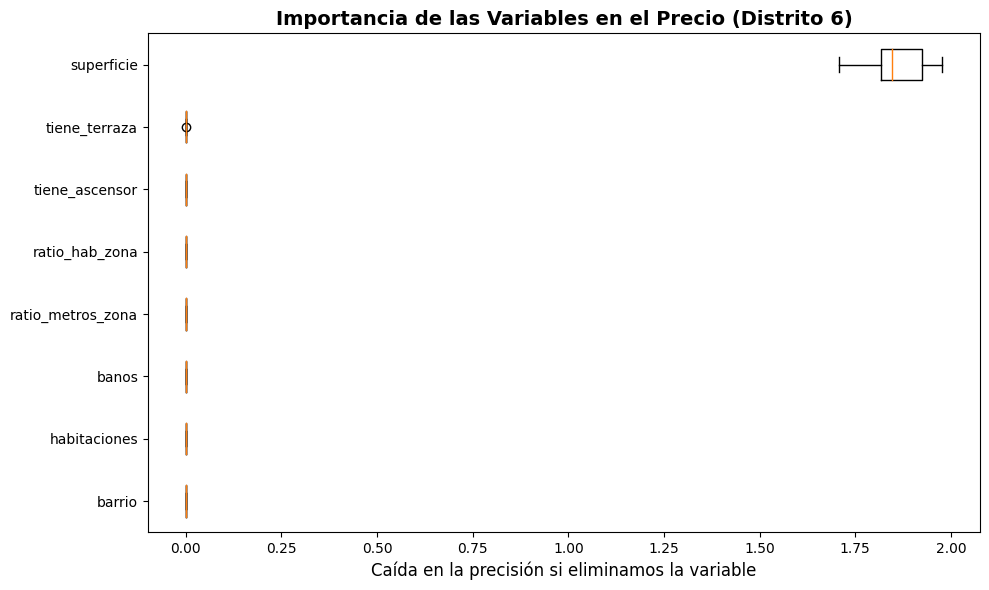

In [5]:
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
import numpy as np

# Extraemos el modelo y el scaler del distrito 6 (como ejemplo)
distrito_ejemplo = 6
modelo_ejemplo = modelos_por_distrito[distrito_ejemplo]['modelo']
scaler_ejemplo = modelos_por_distrito[distrito_ejemplo]['scaler']

# Preparamos los datos de test de ese distrito
df_d6 = df_final[df_final['distrito'] == distrito_ejemplo]
X_d6 = df_d6[features]
y_d6 = df_d6['log_precio']
X_test_d6_scaled = scaler_ejemplo.transform(X_d6) # Usamos todo el distrito para ver la importancia

# Calculamos la importancia mediante permutación
resultado = permutation_importance(modelo_ejemplo, X_test_d6_scaled, y_d6, n_repeats=10, random_state=42)

# Ordenamos de menor a mayor importancia
sorted_idx = resultado.importances_mean.argsort()

# Creamos el gráfico
plt.figure(figsize=(10, 6))
plt.boxplot(resultado.importances[sorted_idx].T, vert=False, labels=np.array(features)[sorted_idx])
plt.title(f"Importancia de las Variables en el Precio (Distrito {distrito_ejemplo})", fontsize=14, fontweight='bold')
plt.xlabel("Caída en la precisión si eliminamos la variable", fontsize=12)
plt.tight_layout()
plt.show()